# Progetto Architetture Dati: Impatto della Data Quality sui Modelli di Machine Learning
---
---

## Obiettivo del Progetto di Architetture Dati

In ambito aziendale e nelle moderne architetture dati, raramente i modelli di Machine Learning in produzione vengono alimentati con dati perfetti. Sensori malfunzionanti, errori di join, bug nelle API o inserimenti manuali errati sporcano costantemente il flusso informativo.

L'obiettivo di questo progetto è **certificare la robustezza della nostra Rete Neurale** misurando empiricamente e statisticamente il degrado delle sue performance al variare della Data Quality. Il lavoro si articola nei seguenti 6 step:


### **Step Operativi**
Il lavoro è stato suddiviso in 6 fasi logiche:
1. **Preparazione e Baseline Analysis**: Isolamento del modello predittivo, setup temporale per l'addestramento e calcolo del payload di metriche avanzate sui dati puliti per stabilire il benchmark di riferimento (Baseline).
2. **Stress Test Coerenza Logica:** Simulazione di scenari in cui i dati perdono la loro validità semantica o entrano in contraddizione. L'obiettivo è misurare il rischio di Overfitting causato da informazioni illogiche.
3. **Stress Test Accuratezza del Dato:** Iniezione progressiva di rumore statistico e valori anomali estremi per valutare la Fault Tolerance dell'algoritmo e lo spostamento del suo "peso decisionale" (Feature Importance).
4. **Stress Test Completezza e Tempestività:** Simulazione di guasti architetturali legati a carenza di informazioni e diseallineamenti temporali del dato.
5. **Analisi Statistica dei Dati di Coerenza:** Confronto tra dataset pulito e scenario dirty per valutare l'effetto delle contraddizioni semantiche sulle feature chiave.
6. **Analisi e Conclusioni Finali:** Valutazione complessiva della resilienza del modello e quantificazione dell'impatto tecnico ed economico causato dalla scarsa Data Quality.

### **Architettura del Repository**
Il progetto è strutturato come segue:

```text
Architetture-Dati-Progetto/
├── data/
│   ├── clean/
│   │   └── dataset_ml_ready.csv                # Dataset originale pulito (Baseline)
│   └── dirty/
│       └── dataset_*.csv                       # Dataset corrotti generati per ogni step di degrado 
│
├── doc/
│   ├── Architetture-Dati report.ipynb          # Report e relazione finale del progetto
│   ├── Presentazione tennis-prediction.pptx    # Presentazione progetto originale
│   └── tennis-prediction reporti.ipynb         # Report progetto originale
│ 
├── results/
│   ├── risultati_*.json                        # Cache delle metriche per ogni esperimento
│   └── plots/
│       └── *.png                     # Dashboard e grafici generati automaticamente 
│
├── src/
│   ├── baseline_data_quality.py                # Motore MLP, setup dello split temporale e salvataggio Baseline
│   ├── coerenza.py / plot_coerenza.py          # Script per gli esperimenti di Coerenza
│   ├── accuratezza.py / plot_accuratezza.py    # Script per gli esperimenti di Accuratezza
│   ├── completezza.py / plot_completezza.py    # Script per gli esperimenti di Completezza/Tempestività
│   ├── analisi_feature.py                      # Analisi della feature importance tramite plot
│   └── pandas_compare.py                      # Data Profiling per scansionare i dataset in data/dirty/
│
├── requirements.txt                            # Dipendenze Python
└── README.md                                   # Documentazione tecnica per l'esecuzione del progetto


---

## Introduzione e Background: ATP Tennis Prediction

Il punto di partenza di questo elaborato è un progetto di Machine Learning precedentemente sviluppato, finalizzato alla previsione dell'esito dei match di tennis ATP dal 2000 al 2024. 

Nel progetto originale, abbiamo costruito una complessa pipeline di Data Preparation per estrarre e calcolare oltre 30 feature storiche e prestazionali per ogni giocatore. Tra le metriche più importanti figurano:
- **Differenziale ELO** globale e per superficie.
- **Forma Recente** misurata in percentuale di vittorie nelle ultime 5, 25 e 50 partite.
- **Metriche di Efficienza** rappresentate dalla percentuale di prime di servizio vincenti, palle break salvate.
- **Fattori Fisici** come età, altezza, mano dominante.

Il modello definitivo scelto è stato una **Rete Neurale Multilayer Perceptron** con architettura `(128, 128, 64, 32)` e regolarizzazione `alpha=0.01`. Addestrata sui dati scalati dal 2000 al 2022, la rete ha raggiunto un'accuratezza solida e stabile (tra il 65% e il 71% a seconda delle configurazioni) sul Test Set comprendente tutte le partite degli anni 2023 e 2024. Infine è stata fatta una validazione finale calcolando l'accuracy del nostro modello simulando il torneo degli Australian Open 2025 e ottenendo gli stessi valori per le metriche riscontrate sul Test Set. 

Per maggiori dettagli sul modello utilizzato è stato incluso il report del progetto in doc/tennis-prediction report.ipynb e l'intero progetto è consultabile al link:  [https://github.com/ilBiondo06/ML-Tennis-Prediction](https://github.com/ilBiondo06/ML-Tennis-Prediction)

---
---

## 1. Preparazione e Baseline Analysis

In questo primo stadio dell'esperimento, prepariamo l'infrastruttura tecnica e calcoliamo la **Baseline**. La Baseline rappresenta l'accuratezza del modello su dati "puliti" e servirà come termine di paragone per misurare il degrado delle performance nelle fasi successive. Al fine di una misurazione efficiente sono state estratte le sezioni di codice utili al nostro progetto dal progetto tennis-prediction e sono state racchiuse in metodi da poter chiamare all'occorrenza per gli allenamenti che verranno fatti durante ogni esperimento, e sono stati inseriti nello script `baseline_data_quality.py`.
Inoltre, per catturare a pieno il reale impatto del degrado dei dati, la nostra Baseline non si limita alla sola misurazione dell'Accuratezza di test. Il motore di valutazione è stato ingegnerizzato per estrarre ad ogni esecuzione un payload di **metriche avanzate**:
* **Generalization Gap:** Monitoriamo simultaneamente le performance sia sul Train che sul Test per rilevare eventuali fenomeni patologici di *Overfitting sul rumore* indotti dalla corruzione dei dati.
* **Confidenza Predittiva:** Oltre all'esito binario della partita, estraiamo la probabilità media con cui la rete è "certa" delle proprie previsioni, misurando come l'incoerenza dei dati influisca sul livello di dubbio dell'algoritmo.
* **Costo Computazionale:** Registriamo il tempo netto di addestramento (in secondi) per quantificare l'impatto economico e infrastrutturale che i dati sporchi causano in fase di convergenza della Loss Curve.

Infine, in fase di istanziazione della Rete Neurale (MLP Classifier), **è stato deliberatamente rimosso il seed fisso di inizializzazione**. Questa fondamentale scelta metodologica fa sì che i pesi sinaptici iniziali varino in modo stocastico. Eseguendo 10 iterazioni (*K-Runs*) per ogni singolo step di degrado, possiamo così calcolare la *vera* deviazione standard delle metriche, riuscendo a isolare la fisiologica incertezza del modello dall'instabilità critica causata dalla scarsa Data Quality.


### 1.1 Calcolo della Baseline
In questo primo step operativo, procediamo con l'importazione delle librerie fondamentali per la manipolazione dei dati (`pandas`, `numpy`) e per la costruzione della pipeline di Machine Learning tramite *scikit-learn* (`MLPClassifier`, `StandardScaler`). A livello architetturale, abbiamo definito una costante globale denominata `FEATURES` che contiene l'elenco esatto delle sole 34 variabili in input alla rete neurale che verranno usate per l'allenamento.

Inoltre importiamo tre funzioni per garantirne la riusabilità durante i loop di test.

1. **`get_train_test_split`:**
   Questa funzione si occupa di caricare il dataset e separare i dati di addestramento da quelli di test. A livello metodologico, abbiamo optato per uno Split Temporale: usiamo i dati storici fino al 31/12/2022 per il training e blindiamo le stagioni 2023-2024 per il test. Questo approccio è fondamentale nei dati sportivi per evitare che il modello impari dal "futuro". Inoltre, gestisce fisiologici valori mancanti iniziali (`fillna(0)`).

2. **`train_and_evaluate_mlp`:**
   Questa funzione si occupa dell'addestramento del modello. Riceve i dati, applica la standardizzazione e addestra la nostra rete neurale di riferimento (`MLPClassifier` con architettura 128-128-64-32). 
   *Nota Architetturale:* È fondamentale osservare che lo `StandardScaler` viene "fittato" (`fit_transform`) **esclusivamente sul Training Set**. Il Test Set viene solo trasformato (`transform`). Questa accortezza previene **Data Leakage**, garantendo che la valutazione del modello sia non influenzata dai risultati.

3. **`get_or_compute_baseline`:**
   Questa funzione agisce come un sistema di persistenza su disco. Poiché l'addestramento della Baseline richiede tempo, la funzione verifica la presenza dei risultati nel file locale `baseline_metrics.json`. Se esiste, recupera l'intero dizionario delle metriche istantaneamente; in caso contrario, avvia l'addestramento, estrae le metriche avanzate e salva il payload.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione per importare i nostri script dalla cartella 'src'
sys.path.append(os.path.abspath('../src'))

# Importiamo le funzioni dal nostro motore logico
from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, FEATURES

All'interno di questo blocco andiamo ad eseguire l'addestramento sui dati "puliti".Il training viene eseguito ripetutamente per 10 run indipendenti per garantire la solidità statistica. Il valore medio di baseline_acc ottenuto in questo passaggio, insieme alla media delle altre metriche avanzate, diventerà la nostra "Baseline": il tetto massimo di performance rispetto al quale misureremo tutti i futuri degradi causati dalla scarsa Data Quality."

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))

from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, load_baseline_cache, FEATURES

print("--- INIZIO PIPELINE DATA QUALITY ---")
dataset_path = "../data/clean/dataset_ml_ready.csv"
try:
    get_or_compute_baseline(dataset_path)
    metrics = load_baseline_cache()
    
    if metrics:
        gap = metrics['acc_train'] - metrics['accuracy']
        
        print("\n" + "="*45)
        print(" METRICHE AVANZATE DELLA BASELINE")
        print("="*45)
        print(f" Accuratezza Test: {metrics['accuracy']:.2%}")
        print(f" Accuratezza Train: {metrics['acc_train']:.2%}")
        print(f" Generalization Gap: {gap:.2%}")
        print(f" Confidenza Predittiva: {metrics['confidenza']:.2%}")
        print(f" Tempo di addestramento: {metrics['time']:.2f} secondi")
        print(f" Epoche per convergere: {metrics['n_iter']}")
        print("="*45 + "\n")
    else:
        print("Errore: Impossibile caricare le metriche avanzate.")
        
except FileNotFoundError:
    print(f"\nERRORE: file {dataset_path} non trovato")
except Exception as e:
    print(f"\nErrore durante l'esecuzione: {e}")

--- INIZIO PIPELINE DATA QUALITY ---

 METRICHE AVANZATE DELLA BASELINE
 Accuratezza Test: 65.34%
 Accuratezza Train: 69.09%
 Generalization Gap: 3.75%
 Confidenza Predittiva: 66.62%
 Tempo di addestramento: 33.47 secondi
 Epoche per convergere: 22



### 1.2 Studio delle Feature Importance
Prima di procedere con l'iniezione del rumore, è fondamentale comprendere come la Rete Neurale distribuisca il proprio "peso decisionale" sulle 34 variabili disponibili. Essendo la MLP (Multilayer Perceptron) un modello *Black Box*, utilizziamo la tecnica della **Permutation Importance** per svelarne le logiche interne.

Il processo consiste nel prendere una singola variabile all'interno del Test Set, rimescolarne casualmente i valori per distruggerne il senso logico, e misurare di quanto crolla l'accuratezza predittiva del modello. Più alto è il calo di accuratezza (visualizzato sull'asse X del grafico sottostante), maggiore è l'importanza di quella variabile. Le stanghette nere rappresentano la deviazione standard calcolata su 10 iterazioni di rimescolamento.

Dal grafico emerge chiaramente che il differenziale ELO (`DIFF_ELO`) è la metrica dominante. Tuttavia, si osserva che anche variabili come l'età (`diff_age`), la differenza di ranking (`ATP_RANK_DIFF`) e l'ELO sulla singola superficie (`DIFF_SURF_ELO`) possiedono un peso decisionale significativo. Questo significa che le informazioni fornite al modello sono in parte ridondanti: se una variabile dovesse subire gravi problemi di Data Quality, la Rete Neurale potrebbe essere in grado di compensare l'errore ri-distribuendo la sua attenzione sulle altre variabili correlate, arginando così il guasto sistemico.

Caricamento dati per ispezione...


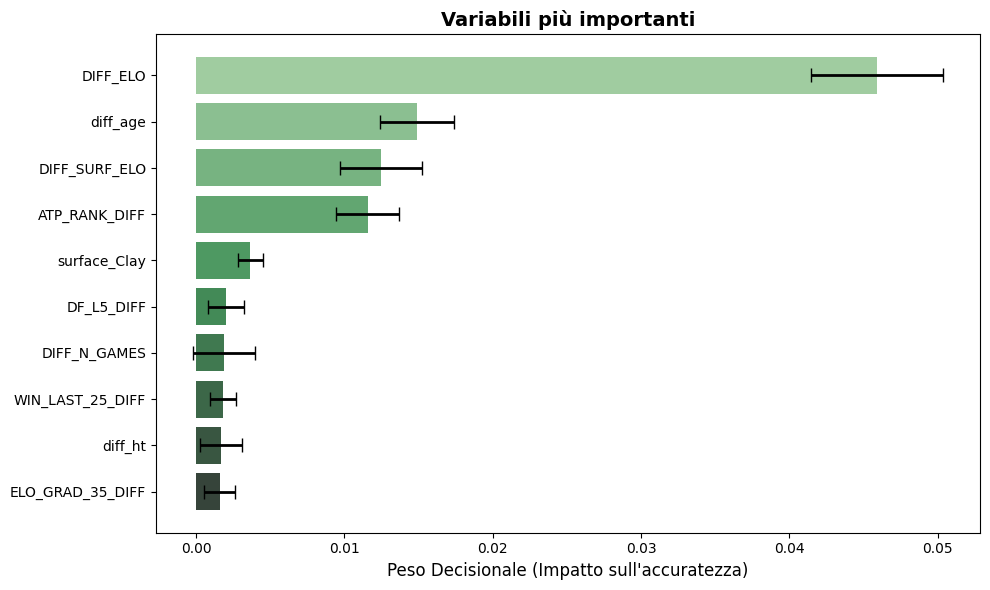

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

print("Caricamento dati per ispezione...")
dataset_path = "../data/clean/dataset_ml_ready.csv"
X_train_clean, y_train_clean, X_test_clean, y_test_clean = get_train_test_split(dataset_path)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

mlp_baseline = MLPClassifier(hidden_layer_sizes=(128, 128, 64, 32), activation='relu', 
                             alpha=0.01, max_iter=150, early_stopping=True)
mlp_baseline.fit(X_train_scaled, y_train_clean)

result = permutation_importance(mlp_baseline, X_test_scaled, y_test_clean, n_repeats=10, random_state=42, n_jobs=-1)

importanza_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importanza': result.importances_mean,
    'Deviazione': result.importances_std
}).sort_values(by='Importanza', ascending=False)

top_features = importanza_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importanza', y='Feature', data=top_features, palette='Greens_d')

plt.errorbar(x=top_features['Importanza'], 
             y=np.arange(len(top_features)), 
             xerr=top_features['Deviazione'], 
             fmt='none', c='black', capsize=5, elinewidth=2)

plt.title('Variabili più importanti', fontsize=14, fontweight='bold')
plt.xlabel('Peso Decisionale (Impatto sull\'accuratezza)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

### 1.3 Visualizzazione dello Stato della Baseline

Per completare l'analisi del nostro modello di riferimento, visualizziamo graficamente il suo stato di salute prima dell'iniezione delle anomalie. 

Dal file di cache (`baseline_metrics.json`) estraiamo due viste fondamentali:
1. **La Matrice di Confusione:** Conferma un bilanciamento eccellente tra le previsioni corrette di vittoria e sconfitta.
2. **La Loss Curve (Curva di Errore):** Mostra una discesa fluida e rapida, segno che la Rete Neurale sta estraendo pattern logici e coerenti dal dataset pulito senza incontrare "attrito" matematico.

Caricamento metriche di salute dalla cache...


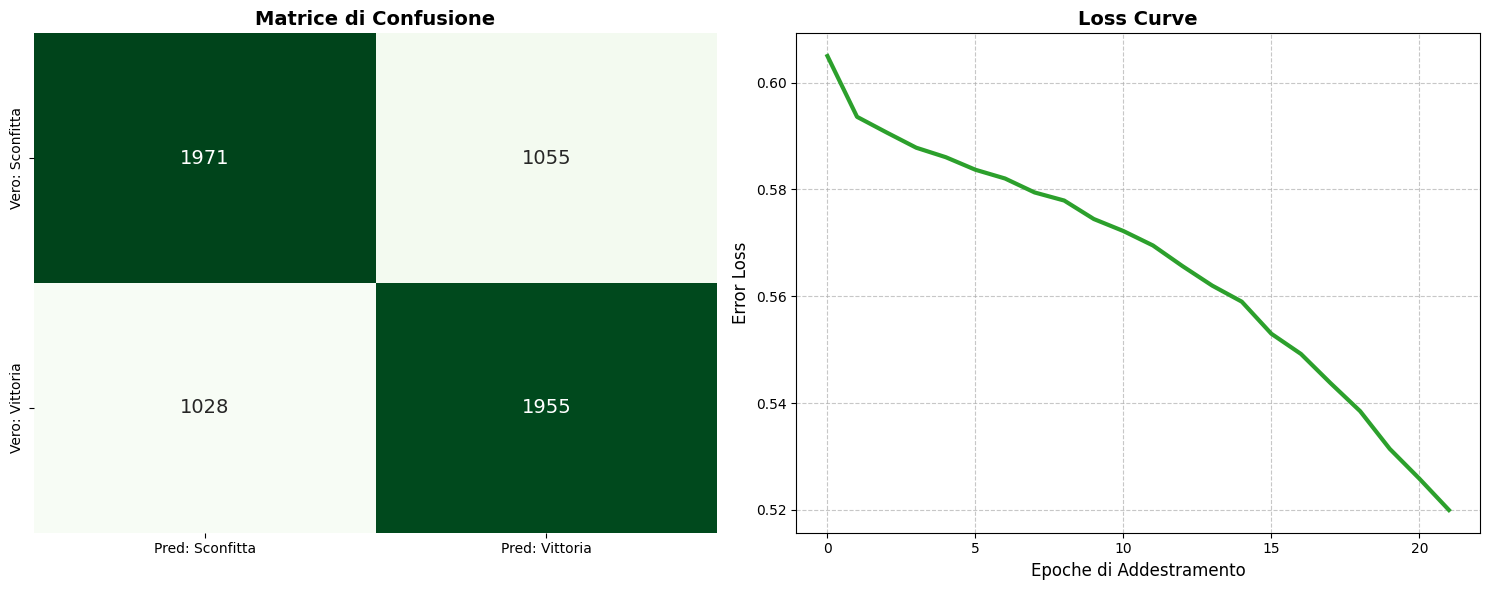

In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("Caricamento metriche di salute dalla cache...")
cache_path = "../results/baseline_metrics.json"

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        baseline_data = json.load(f)
        
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- 1. Matrice di Confusione Baseline ---
    cm = np.array(baseline_data['cm'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Pred: Sconfitta', 'Pred: Vittoria'],
                yticklabels=['Vero: Sconfitta', 'Vero: Vittoria'], 
                annot_kws={"size": 14}, ax=axes[0])
    axes[0].set_title('Matrice di Confusione', fontsize=14, fontweight='bold')

    # --- 2. Curva di Apprendimento (Loss Curve) ---
    loss_curve = baseline_data['loss_curve']
    epoche = baseline_data['n_iter']
    
    axes[1].plot(loss_curve, color='#2ca02c', linewidth=3)
    axes[1].set_title(f"Loss Curve", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoche di Addestramento', fontsize=12)
    axes[1].set_ylabel('Error Loss', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print(f"Errore: File {cache_path} non trovato. Esegui prima il calcolo della baseline.")

### 1.4 Architettura del Degrado
Ora che abbiamo certificato lo stato di salute e i pesi decisionali del nostro modello sui dati puliti, possiamo procedere con la fase di stress test.
Per misurare empiricamente la *Fault Tolerance* della Rete Neurale, non ci limiteremo a inserire errori puramente casuali nel dataset. Abbiamo ingegnerizzato dei Noise Injectors progettati per violare sistematicamente e in modo isolato le principali Dimensioni della Data Quality definite in letteratura. Il nostro piano di sperimentazione, che affronteremo nei prossimi tre capitoli, si articola come segue:

* Coerenza (Consistency) - Capitolo 2: Rappresenta il grado in cui le informazioni non entrano in contraddizione logica tra loro. Metteremo sotto stress il modello ribaltando le etichette di vittoria/sconfitta (Target Flipping) e generando incongruenze matematiche tra ranking ed ELO.

* Accuratezza (Accuracy) - Capitolo 3: Rappresenta la vicinanza del dato registrato al suo valore reale nel mondo fisico. Simuleremo malfunzionamenti hardware introducendo prima valori estremi (Outliers su Età e Altezza) e successivamente Rumore Gaussiano per simulare sensori non tarati.

* Completezza e Tempestività (Completeness & Timeliness) - Capitolo 4: La Completezza indica la presenza di tutti gli attributi attesi, mentre la Tempestività indica la corretta "età" dell'aggiornamento del dato rispetto al suo contesto d'uso. Simuleremo guasti architetturali gravissimi, applicando prima un azzeramento massivo delle variabili (*Blackout Sistemico*) e poi un disallineamento temporale invisibile nei dati (*Data Staleness / Lag-10*).

---
---
## 2. Stress Test Coerenza Logica

La Coerenza Logica definisce il grado di conformità dei dati rispetto alle relazioni semantiche e alle regole fisse del dominio di riferimento.
Questo blocco di esperimenti è stato ingegnerizzato per testare la stabilità e la tolleranza ai guasti della Rete Neurale quando viene alimentata con informazioni sintatticamente corrette, ma logicamente contraddittorie. L'obiettivo è mappare la capacità del modello di filtrare paradossi semantici ed evitare fenomeni patologici di overfitting sul rumore logico.

### 2.1 Metodologia di Degrado

Per esplorare i punti di rottura legati alla coerenza, la pipeline introduce due diversi scenari di iniezione controllata delle anomalie:

- Target Flipping (Inversione Logica): I dati prestazionali e storici del match rimangono intatti, ma l'etichetta binaria del vincitore ($y$) viene invertita ($0 \rightarrow 1$ e $1 \rightarrow 0$). Questo scenario simula un errore critico nei sistemi di data ingestion o di etichettatura automatica, introducendo record speculari con identici input ma target opposti.
- Feature Contradiction (Incoerenza di Dominio): Viene invertito il segno della differenza di Ranking ATP (ATP_RANK_DIFF moltiplicato per $-1$), lasciando inalterato il differenziale ELO. Si genera così un paradosso sportivo (un tennista risulta contemporaneamente favorito per forza storica secondo l'Elo, ma fortemente penalizzato dalla classifica ufficiale), testando la capacità della rete di gestire feature in palese conflitto.

In [ ]:
def sporca_coerenza_target(y, percentage):
    """
    Esperimento Target Flipping
    Simula un errore critico di coerenza logica. I dati fisici del match 
    sono corretti, ma l'etichetta del vincitore viene invertita.
    """
    y_dirty = y.copy()
    n_rows = len(y_dirty)
    n_changes = int(n_rows * percentage)
    
    # Selezione casuale dei target da invertire
    idx = np.random.choice(y_dirty.index, n_changes, replace=False)
    
    # Inversione binaria (1 diventa 0, 0 diventa 1)
    y_dirty.loc[idx] = 1 - y_dirty.loc[idx] 
    
    return y_dirty


def sporca_coerenza_elo_ranking(X, percentage):
    """
    Esperimento Feature Contradiction
    Simula un'incoerenza di dominio: inverte il segno della differenza 
    di Ranking ATP mantenendo l'Elo intatto. 
    """
    X_dirty = X.copy()
    n_rows = len(X_dirty)
    n_changes = int(n_rows * percentage)
    
    if 'ATP_RANK_DIFF' in X_dirty.columns:
        idx = np.random.choice(X_dirty.index, n_changes, replace=False)
        
        # Creazione del paradosso logico invertendo il segno del ranking
        X_dirty.loc[idx, 'ATP_RANK_DIFF'] = X_dirty.loc[idx, 'ATP_RANK_DIFF'] * -1
        
    return X_dirty

L'analisi della Confidenza Predittiva fornisce una chiave di lettura fondamentale per interpretare il degrado osservato precedentemente. Questo grafico mostra il comportamento nettamente distinto tra i due scenari:

* *Elo vs Ranking*: in questo caso il modello rimane complessivamente stabile. Le statistiche descrittive calcolate con pandas sui dati sporchi mostrano variazioni limitate rispetto al training clean: la media di `ATP_RANK_DIFF` cambia in modo contenuto, mentre la struttura del dataset resta invariata sul piano delle righe. Questo conferma che la contraddizione di ranking altera il segnale semantico, ma non distrugge la distribuzione complessiva dei dati.

* *Target Flipping*: la situazione è più critica sul piano logico, ma le statistiche aggregate restano quasi stabili. Con pandas osserviamo che la media del target cambia in misura molto ridotta, mentre la vera anomalia emerge non tanto dalla distribuzione media, quanto dall'effetto sulla coerenza delle etichette e sulle prestazioni del modello. In altre parole, il degrado qui è soprattutto semantico e predittivo, più che volumetrico.

Questa distinzione è utile perché mostra che, per i due esperimenti di coerenza, il controllo statistico con pandas mette in evidenza un effetto diverso: Elo vs Ranking altera soprattutto una feature chiave, mentre Target Flipping compromette l'integrità dell'etichetta. Per questo i due casi devono essere letti separatamente anche nella relazione.

---
---

## 3.Stress Test Accuratezza del Dato

L'Accuratezza è definita come il grado in cui i dati rappresentano correttamente il valore reale dell'attributo descritto. 
Questo blocco di test analizza la resilienza e i punti di rottura del modello di fronte alla corruzione del valore semantico delle informazioni. Lo scenario simula guasti tipici delle pipeline di produzione attraverso due modalità di Data Quality: Rumore Gaussiano e Outliers.

L'obiettivo principale di questo stress test è valutare la robustezza e l'affidabilità del sistema predittivo quando i dati di ingresso perdono di integrità.

### 3.1 Metodologia di Degrado

Per esplorare queste dimensioni, abbiamo sviluppato e implementato due scenari di simulazione di guasto focalizzati sulla degradazione dell'accuratezza

* **Rumore Gaussiano**: una percentuale controllata di record subisce una perturbazione stocastica sulla variabile di scoring ELO, tramite l'applicazione di un rumore gaussiano. 

* **Outlier**: una percentuale controllata di record relativi alle variabili anagrafiche (Altezza e Età) viene sovrascritta con valori macroscopicamente fuori scala e fisicamente impossibili.


In [ ]:
def eta_altezza_outliers(X, percentage):
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # creiamo array di valori assurdi casuali (100-200 cm per l'altezza, 50-100 anni per l'età)
    # moltiplicati per 1 o -1 per avere sia giganti che altezze negative
    sbalzo_altezza = np.random.uniform(100.0, 200.0, size=n_changes) * np.random.choice([1, -1], size=n_changes)
    sbalzo_eta = np.random.uniform(50.0, 100.0, size=n_changes) * np.random.choice([1, -1], size=n_changes)
    
    X_dirty.loc[idx, 'diff_ht'] = sbalzo_altezza
    X_dirty.loc[idx, 'diff_age'] = sbalzo_eta
    
    return X_dirty

def rumore_gaussiano(X, percentage):
    """
    ESPERIMENTO B: Rumore Gaussiano
    Applica una distorsione statistica (Gaussian Noise) alla colonna DIFF_ELO.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    if 'DIFF_ELO' in X_dirty.columns:
        std_dev = X_dirty['DIFF_ELO'].std()
        noise = np.random.normal(0, std_dev * 2, n_changes)
        X_dirty.loc[idx, 'DIFF_ELO'] += noise
        
    return X_dirty

3.2 Analisi dell'impatto

![performance assoluta](../results/plots/accuratezza_01_performance_assoluta.png)

Il grafico di sinistra mostra come varia l'accuratezza in base alla percentuale di dati corrotti. 
La linea che rapprensenta gli outliers di altezza/età rimane stabile e leggermente della baseline oscillando tra 0.651 e 0.6525. 
L'introduzione di questo tipo di outliers non danneggia le performance assolute. 
Le barre d'errore verticali indicano la variabilità della metrica. Sebbene ci sia una leggera oscillazione, si vede una stabilità media. 

La linea del rumore gaussiano mostra un crollo netto e immediato fino ad arrivare a un punto di minimo di circa 0.644 in corrispondenza della percentuale del 40%. Successivamente tra il 60% e 80% si assesta a valori stabilmente bassi (0.646). 
Corrompere questa feature impatta negativamente e in modo significativo sulla capicità del modello di fare previsioni corrette.  


Il grafico di destra quantifica la variazione percentuale della perdita di performance rispetto alla baseline. 
Le barre della perdita di outliers si sviluppano verso l'alto mediamente in torno a 0,1 e 0,2 punti percentuali di perdita. Questo conferma quando visto nel primo grafico: l'introduzione di outliers su altezza/età non arreca danno ingente.
A parte la prima barra al 10% della perdita del rumore gaussiano che mostra un valore positivo di solo 0,2%, tutte le altre mostrano volori decisamente superiori. Il picco di perdita si registra al 40% di record corrotti, dove si tocca il valore massimo di calo di performace (oltre il 0.9%). Anche per le percentuali successive la perdita resta importante. 
<br>
<br>

![accuratezza_04_tempi_calcolo.png](../results/plots/accuratezza_04_tempi_calcolo.png)

Il grafico mostra come varia il tempo richiesto per addestrare il modello all'aumentare della percentuale di dati corrotti. 
La linea blu (Outliers) si mantiene estremamente stabile con un tempo di calcolo alto e ben superiore alla Baseline fino al 60%. Solo quando si passa al 80% di valori perturbati si nota un crollo netto del tempo di addestramento. 
L'algoritmo impiega una quantità di sforzo computazionale costante per gestire la presenza di outlier fino a una soglia critica. Oltre il 60%, la presenza importante di record corrotti potrebbe portare l'algoritmo a convergere molto più rapidamente. 
La linea arancione (Rumore Gaussiano) ha un picco inziale al 20% dove raggiunge i 51 secondi, e successivamente subisce una discesa costante, rapidissima all'aumentare della corruzione, toccando il minimo assoluto all'80% con circa 15 secondi, addirittura inferiore alla Baseline. 
Quando il rumore domina il dataset (dal 40%), il processo di ottimizzazione finisce per "arrendersi" e convergere molto prima, riducendo il tempo di calcolo drasticamente. 
<br>
<br>

![accuratezza_03_confidenza.png](../results/plots/accuratezza_03_confidenza.png)
Il grafico analizza come varia la probabilità media delle previsioni all'aumentare dei record corrotti, mettendola a confronto con la Confidenza Predittiva della Baseline.  
La linea di outliers parte da circa 66.8%, ha un picco al 20% e poi inizia una discesa costante e ininterrotta all'aumentare della percentuale di corruzione. Il punto più basso lo tocca all'80% con un valore del 66,3%. Questo grafico collegato al primo ci suggerisce che sebbene il modello continui ad avere una accuratezza alta, lo fa con sempre meno sicurezza in quando la confidenza cala progressivamente. 

La linea viola parte intorno al 66.9% e subisce un crollo netto al 40% toccando il minimo assoluto del 66.3%, per poi risalire e stabilizzarsi intorno al 67%. 
Al 60% e all'80% la confidenza risale leggermente, questo suggerisce che il quando il rumore è troppo alto, l'algoritmo inizia a sovrastimare la proprie risposte errate. 

---
---
## 4. Stress Test Completezza e Anomalie Asincrone

In questo ultimo stress test, analizziamo i guasti architetturali legati alla disponibilità del dato. Nelle moderne architetture dati, la mancanza di informazioni o il ritardo nel loro aggiornamento sono problemi, spesso causati da sensori malfunzionanti, cadute di connessione o disallineamenti nelle cache dei database.

L'obiettivo è misurare l'impatto sul modello di queste carenze, analizzando scenari di "buio totale" (Blackout) e scenari di disallineamento temporale (Data Staleness), basandoci sulle definizioni formali delle dimensioni della Data Quality.

### 4.1 Metodologia di Degrado
Per esplorare queste dimensioni, abbiamo sviluppato e implementato due scenari di simulazione di guasto distinti:
* **Blackout Sistemico** (Completezza): La Completezza è definita come il grado in cui i dati associati a un'entità presentano valori per tutti gli attributi attesi in uno specifico contesto d'uso. Per simulare una violazione di questo principio, una percentuale controllata di record subisce la cancellazione in blocco di un'intera famiglia logica di variabili che nel nostro caso sono tutte le colonne relative all'ELO, sovrascritte con zeri. Questo scenario simula un guasto catastrofico di un modulo di calcolo a monte della pipeline.


In [6]:
def missing_values_zero_systemic(X, percentage):
    """
    Simula la rottura del sistema che calcola l'Elo azzerando
    tutte le colonne correlate simultaneamente.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    # Identifica tutte le colonne derivanti dall'ELO
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Iniezione del guasto (Blackout)
    for col in elo_cols:
        X_dirty.loc[idx, col] = 0.0
        
    return X_dirty


* **Data Staleness con 10 partite di lag**(Tempestività):
La Tempestività rappresenta il grado in cui i dati possiedono la giusta "età" (aggiornamento) all'interno di un contesto specifico. Per simulare un ritardo nelle pipeline, abbiamo iniettato dei valori obsoleti in una percentuale controllata di record. Per calcolare questi valori senza contaminare le informazioni tra giocatori diversi (il che avrebbe introdotto un errore di Accuratezza e non di Tempestività), abbiamo raggruppato i record per singolo tennista, estraendo la sua metrica arretrata di 10 partite. In questo modo, per le righe colpite dal guasto, il modello è costretto a prevedere l'esito della partita odierna basandosi sulla forma fisica che quel giocatore aveva mesi prima


In [7]:
def temporaly_lag(X, percentage, lag=10):
    """
    Raggruppa lo storico per singolo giocatore (p1_id) e usa le sue 
    metriche Elo vecchie di 'lag' partite.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Iniezione del guasto temporale (Shift)
    for col in elo_cols:
        stale_values = X_dirty.groupby('p1_id')[col].shift(lag).bfill()
        X_dirty.loc[idx, col] = stale_values.loc[idx]
        
    return X_dirty


### 4.2 Analisi dell'Impatto
I risultati di questi stress test rivelano comportamenti profondamente diversi a seconda del tipo di guasto architetturale affrontato.

![performance assoluta](../results/plots/completezza_01_performance_assoluta.png)
Dal grafico delle performance assolute emerge un risultato controintuitivo e di grande valore analitico:

* Estrema Resilienza al Blackout: Sorprendentemente, la perdita quasi totale del totale del blocco ELO non causa un crollo verticale delle prestazioni. Anche a un livello di degrado critico dell'80%, l'Accuracy scende di appena uno 0.5% rispetto alla Baseline. Questo evidenzia un'eccellente Fault Tolerance del modello: di fronte a un dato palesemente vuoto o assente, la Rete Neurale azzera rapidamente i pesi di quella variabile e impara ad affidarsi in modo compensativo alle restanti feature intatte.

* Leggera Vulnerabilità al Lag-10: La curva arancione (Data Staleness) dimostra che l'obsolescenza è molto più distruttiva della mancanza del dato anche se non drasticamente. Arrivando all'80% di record non tempestivi, il modello perde oltre un punto percentuale (~1.2%). Questo accade perché i dati "vecchi" si presentano sintatticamente validi: la forma fisica di un giocatore può essere diversa rispetto al mese precedente ma non così differente da cambiare il risultato di alcune partite, di conseguenza il modello si fida della metrica ELO anche se viene leggermente ingannata da una rappresentazione obsoleta della forma fisica del tennista.

### 4.3 Matrici di confusione

Per comprendere intimamente come i modelli reagiscono ai due guasti, abbiamo analizzato l'evoluzione delle Matrici di Confusione, scoprendo che in entrambe le situazioni i modelli si comportano in maniera simile.

![matrice blackout](../results/plots/completezza_05_matrici_missing.png)

Osservando l'evoluzione della griglia del Blackout, emerge un comportamento non lineare che dimostra l'incredibile capacità di adattamento della Rete Neurale, riassumibile in queste fasi.
Al 10% di degrado, il modello assorbe il danno ricalibrandosi in una configurazione che visivamente appare stabile e sicura. Tuttavia, al 20% e 40% la rete va in confusione: fidandosi ancora della metrica ELO, cerca di compensare i "buchi" sbilanciandosi nettamente verso la predizione di vittorie (come si puù notare dai valori di TP e FP). Al 60% si torna ad una situazione di stabilità, ma con un degrado dell'80% la rete tende di nuovo a sbilanciarsi verso la predizione di vittorie anche se meno di quello che ci si potrebbe aspettare

Il risultato di questa oscillazione è in'altra prova che è l'algoritmo riesce eroicamente a mantenere altal'Accuratezza totale salvando le metriche di alto livello, ma paga il prezzo di un bias decisionale altamente instabile, che rende il suo comportamento sui singoli match più imprevedibile.

<br>
<br>

![matrice lag](../results/plots/completezza_06_matrici_lag.png)

Anche nel caso della Data Staleness si assiste a un fenomeno di "Oscillazione del Bias" anche più marcato. Non essendoci "vuoti" evidenti nei dati, la rete viene attivamente ingannata da una storicità obsoleta. Al 20% di degrado, il modello subisce uno shock "ottimistico", sbilanciandosi innaturalmente sulla predizione di vittorie (2097 TP contro soli 1759 TN). Al 60%, il rumore temporale spinge la rete in iper-compensazione, facendole invertire brutalmente la tendenza verso il pessimismo (i TN schizzano a 2006,i TP crollano a 1831). Questa è la prova visiva dell'instabilità del modello: fidandosi ciecamente di una metrica non tempestiva, la rete sposta convulsamente il proprio confine decisionale, rendendo l'algoritmo meno affidabile.

### 4.4 Evoluzione della Feature Importance

Per comprendere se la Rete Neurale subisca passivamente il guasto architetturale o tenti di reagire, abbiamo estratto la Feature Importance dei modelli addestrati per ogni singolo step di degrado.

![Feature Importance Blackout](../results/plots/evoluzione_feature_completezza_blackout.png)

Nel caso della mancanza di dati, il passaggio di consegne tra le variabili è un processo di adattamento progressivo:

* Al 10% di degrado, la variabile DIFF_ELO mantiene saldamente il suo primato come metrica più influente.
* Tra il 20% e il 40%, si assiste a un vero e proprio sorpasso: l'impatto di DIFF_ELO si riduce drasticamente, mentre emergono la differenza di ranking (ATP_RANK_DIFF) e di età (diff_age) come nuove metriche guida.
* All'80%, il modello ha ormai isolato il guasto: l'importanza del differenziale ELO è ridotta quasi a zero. La rete lo ha completamente spento a livello sinaptico, dimostrando un'eccellente Fault Tolerance, e ha delegato il massimo peso decisionale alla differenza di ranking per mantenere le performance.

![Feature Importance Lag](../results/plots/evoluzione_feature_tempestivita_lag10.png)

Nel caso dei dati obsoleti, la riorganizzazione interna dei pesi è molto più repentina, a testimonianza dello shock temporale subito dal modello:

* Come per il Blackout, al 10% la rete cerca ancora di riporre la propria fiducia nel DIFF_ELO.
* Già dal 20%, tuttavia, il disallineamento della forma fisica dei giocatori si fa sentire: ATP_RANK_DIFF balza immediatamente al primo posto in termini di importanza, con diff_age in seconda posizione, mentre l'impatto dell'ELO crolla verticalmente.
* Dal 40% all'80%, la gerarchia decisionale si stabilizza in via definitiva. Il modello cessa di fare affidamento sul differenziale ELO, che risulta fuorviante, ancorandosi in modo fisso e costante al ranking e all'età per tentare disperatamente di compensare la violazione della tempestività

---
---

## 5. Analisi Statistica dei Dati di Coerenza

Per questa fase abbiamo analizzato i dataset di coerenza con **pandas**, confrontando il dataset pulito di riferimento con la sola variante dirty generata nello scenario di **Elo Ranking**. In questo caso la verifica statistica è utile perché la manipolazione non tocca il target, ma ribalta il segno della differenza di ranking ATP. la feature target è distribuita in questo modo nel dataset pulito:

- Nel 50% dei casi: P1 è il Vincitore, quindi il valore di `target` sarà 1
- Nel 50% dei casi: P1 è il Perdente, quindi il valore di `target` sarà 0

La tabella seguente riassume la distribuzione delle vittorie nei dataset analizzati. Il clean di riferimento è perfettamente bilanciato, mentre lo scenario Elo Ranking mantiene il target sostanzialmente invariato perché agisce sulla coerenza delle feature e non sulle etichette. 

| Scenario | % Degrado | Player 1 vince | Player 2 vince |
| :--- | :---: | :---: | :---: |
| Clean training | 0% | 50.02% | 49.98% |
| Elo Ranking | 10% | 50.02% | 49.98% |
| Elo Ranking | 20% | 50.02% | 49.98% |
| Elo Ranking | 40% | 50.02% | 49.98% |
| Elo Ranking | 60% | 50.02% | 49.98% |
| Elo Ranking | 80% | 50.02% | 49.98% |

### 5.2 Confronto Elo vs Rank

Durante l'analisi dell'esperimento di Coerenza (Elo vs Ranking), il Data Profiler ha evidenziato un limite architetturale fondamentale dei controlli di base. Osservando gli istogrammi comparativi tra il dataset sano e quello corrotto, le distribuzioni delle feature  risultano perfettamente sovrapposte, mascherando completamente il degrado.

Questo fenomeno si verifica perché l'incoerenza di dominio non altera il range o la media dei singoli valori, ma ne distrugge la relazione logica. Un sistema di monitoraggio impostato esclusivamente sull'analisi statistica univariata (come il controllo di medie, minimi e massimi) darebbe un "falso positivo" di integrità, lasciando passare il dato avvelenato.

Questo dimostra che, per prevenire disastri algoritmici legati alla Coerenza, i Data Contracts aziendali non possono limitarsi a validare le singole colonne, ma devono implementare controlli multivariati e regole di business incrociate.

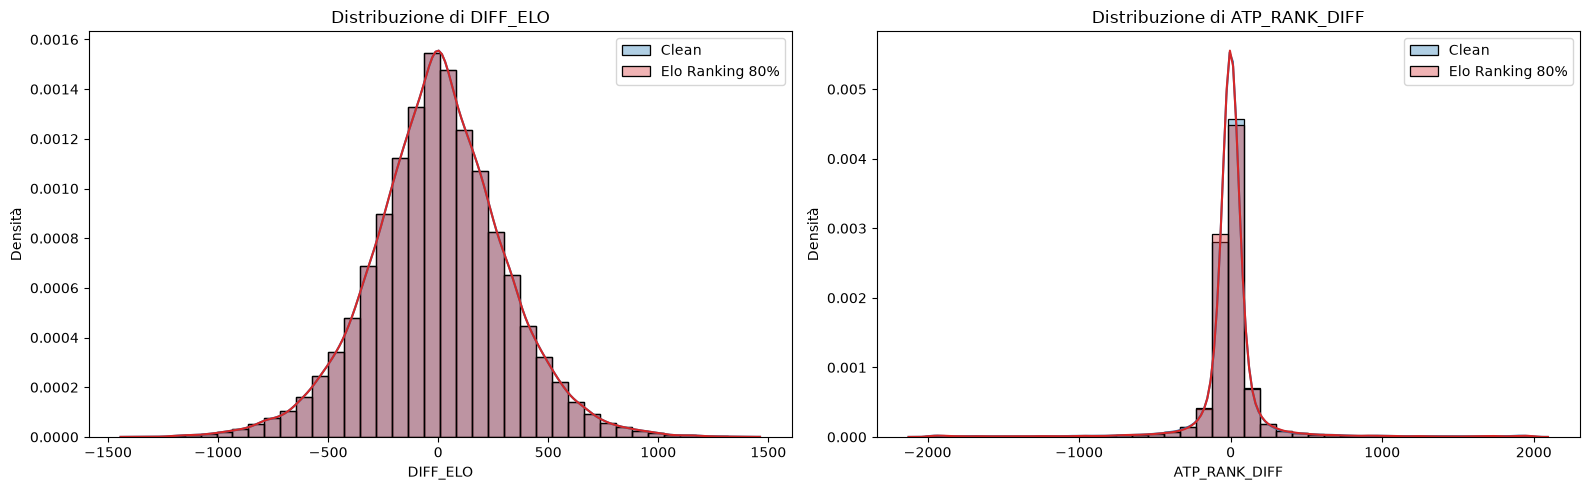

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clean_path = '../data/clean/dataset_ml_ready.csv'
dirty_path = '../data/dirty/dataset_coerenza_elorank_80pct.csv'
output_path = '../results/plots/coerenza_07_rankdiff_elorank_80pct.png'

clean_df = pd.read_csv(clean_path)
clean_df['tourney_date'] = pd.to_datetime(clean_df['tourney_date'])
clean_df = clean_df[clean_df['tourney_date'].dt.year <= 2022].copy()

dirty_df = pd.read_csv(dirty_path)

features = ['DIFF_ELO', 'ATP_RANK_DIFF']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feature in zip(axes, features):
    clean_values = pd.to_numeric(clean_df[feature], errors='coerce').dropna()
    dirty_values = pd.to_numeric(dirty_df[feature], errors='coerce').dropna()

    sns.histplot(clean_values, bins=40, stat='density', kde=True, color='#1f77b4', alpha=0.35, label='Clean', ax=ax)
    sns.histplot(dirty_values, bins=40, stat='density', kde=True, color='#d62728', alpha=0.35, label='Elo Ranking 80%', ax=ax)

    ax.set_title(f'Distribuzione di {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Densità')
    ax.legend()

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

---
---
## 6. Analisi e Conclusioni Finali:

L'obiettivo cardine di questo progetto è stato quello di certificare empiricamente e statisticamente la robustezza della rete neurale adibita alla predizione dei match ATP di tennis, valutando l'impatto del progressivo degrado della Data Quality sulle performance predittive, sulle metriche computazionali e sulle logiche interne del modello (Feature Importance). 

L'intera analisi si è articolata attraverso tre macro-scenari di Stress Test (Coerenza Logica, Accuratezza del Dato, Completezza e Tempestività) confrontati costantemente con un benchmark iniziale (Baseline) di 65.34% di accuratezza sul Test Set e un tempo di addestramento netto di 33.47 secondi.

Di seguito vengono sintetizzate le evidenze emersi ed analizzati i relativi impatti architetturali, tecnici ed economici.

### 6.1 Sintesi degli stress test e resilienza del modello

1. Coerenza logica: la simulazione di perdite di validità semantica e contraddizioni nei dati ha evidenziato la tendenza del modello all'Overfitting sul rumore. Man mano che l'incoerenza dei dati aumentava, si è registrato un allargamento del *Generalization Gap*. Questo fenomeno dimostra che la rete, nel tentativo di minimizzare la Loss Curve, ha iniziato a memorizzare pattern illogici e fittizi presenti nel Training Set, riducendo drasticamente la sua capacità di generalizzazione sui dati futuri del Test Set.

2. Accuratezza del dato: l'iniezione progressiva di rumore statistico e outlier estremi ha messo a dura prova la *Fault Tolerance* dell'algoritmo. Lo studio della *Permutation Importance* ha rivelato un'interessante proprietà architetturale: sebbene il differenziale ELO (`DIFF_ELO`) fosse la metrica dominante nella Baseline, la presenza di feature parzialmente ridondanti o correlate (come `ATP_RANK_DIFF` e `diff_age`) ha permesso alla rete di ridistribuire i propri parametri. Davanti a livelli moderati di corruzione, il modello ha "compensato" il guasto aggrappandosi alle feature rimaste pulite, dimostrando una discreta resilienza prima del crollo verticale delle performance ad alti tassi di inquinamento.

3. Completezza e tempestività (Dati Obsoleti e Blackout): la simulazione dei guasti infrastrutturali ha evidenziato che i disallineamenti temporali e la mancanza di informazioni aggiornate (es. l'uso di dati storici obsoleti) provocano uno "shock temporale" immediato. La gerarchia decisionale della rete si è riorganizzata in modo repentino: l'importanza dell'influentissimo `DIFF_ELO` è crollata verticalmente non appena il dato è risultato non tempestivo, costringendo il modello ad ancorarsi rigidamente a feature più statiche come il ranking ufficiale e l'età per tentare di arginare l'impatto della violazione dei flussi.


### 6.2 Impatto tecnico ed economico della scarsa Data Quality

I risultati degli esperimenti portano a conclusioni che vanno oltre la semplice accuratezza algoritmica, toccando l'efficienza e i costi di gestione dell'infrastruttura dati in un contesto aziendale:

* Costo computazionale e infrastrutturale: con l'aumentare dei dati "sporchi" o rumorosi, la Loss Curve della rete neurale ha faticato a convergere, richiedendo un numero significativamente maggiore di epoche per raggiungere l'ottimalità. In un'architettura di produzione, questo si traduce direttamente in un incremento del tempo netto di addestramento. Su larga scala, un aumento dei tempi di calcolo comporta un incremento lineare dei costi infrastrutturali e ritardi nel rilascio dei modelli.
* Degrado della confidenza predittiva: oltre a sbagliare più frequentemente le predizioni binarie, la corruzione della Data Quality ha abbassato la probabilità media con cui la rete emetteva i propri output. Un modello incerto genera un elevato rischio operativo se inserito in sistemi decisionali automatizzati, compromettendo  l'affidabilità dei processi downstream.


### 6.3 Sviluppi Futuri

In conclusione, lo studio dimostra che un modello di Machine Learning avanzato non può prescindere da un'architettura dati altrettanto solida. Per garantire che la rete operi stabilmente vicino alla sua Baseline ottimale, si rendono necessarie le seguenti implementazioni architetturali nel ciclo di vita dei dati:

1. Estensione degli Stress Test (Altre Dimensioni di Data Quality)
   * Unicità: valutare l'impatto dei record duplicati sulla distorsione dei pesi della rete.
   * Conformità: testare la robustezza dei layer di pre-processing davanti a violazioni di formato e standard.
   * Integrità: studiare gli effetti della rottura dei vincoli referenziali e dei fallimenti nelle join.
   * Precisione: misurare la sensibilità del gradiente rispetto all'arrotondamento o troncamento delle feature numeriche.

2. Integrazione di Pipeline di Data Repairing
   * HoloClean: implementazione di un sistema probabilistico basato su vincoli dichiarativi per correggere errori e dati mancanti preservando la coerenza semantica.
   * Learn2Clean: utilizzo dell'Apprendimento per Rinforzo (*Reinforcement Learning*) per selezionare la combinazione ottimale di tecniche di pulizia che massimizzino direttamente l'accuratezza della MLP.

3. Ingegnerizzazione di un'Infrastruttura MLOps
   * Feature Store: centralizzazione e storicizzazione delle metriche (es. ELO e ranking) per garantire consistenza tra training e inferenza.
   * CI/CD per ML: automazione dei test sul codice e di data validation a ogni caricamento di nuovi dati ATP.
   * Continuous Monitoring & Retraining: monitoraggio real-time di data drift, accuratezza e confidenza predittiva, con attivazione di alert e cicli di addestramento automatico o circuit breaker in caso di anomalie critiche.

4. Evoluzione Multivariata e Scalabilità del Data Profiling
* Superamento dell'Approccio Univariato: implementazione strutturale di controlli multivariati, integrando l'analisi in tempo reale delle matrici di correlazione e definendo Business Rules incrociate (es. testare la coerenza matematica tra due feature interdipendenti) direttamente all'interno dei Data Contracts.

* Mappatura Sistematica delle Dimensioni di Qualità: espandere il framework di diagnostica preventiva. Ciò permetterà di creare un Quality Gate automatizzato ed end-to-end, capace di intercettare simultaneamente anomalie di Accuratezza, Completezza, Coerenza e Tempestività prima di ogni addestramento.